# Simulated go-to tour over the deskewed playfield

The raw camera frame is **deskewed (top-down rectified)** using the camera's
stored full-field calibration homography (134×89 cm, A1 centered — the same one
the aprilcam viewer uses). A **simulated** robot tour is drawn on top: each
iteration ranks the 16 colored targets (8 rectangles + 8 dots) by distance,
drops the closest 4, and picks one at random; the firmware **`G` arc go-to**
(`turnGate=35`) drives there in simulation. **Each segment is colored by its
target**, and each hop stops on the tag.

On the rectified image, world→pixel is a simple linear scale (px/cm).

In [1]:
%matplotlib inline
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")
import math, subprocess, pathlib, sys, random, json
import numpy as np
import cv2
import matplotlib.pyplot as plt

CWD = pathlib.Path.cwd()
REPO = CWD.parent if CWD.name == "host_tests" else CWD
HOST = REPO / "host"
if str(HOST) not in sys.path:
    sys.path.insert(0, str(HOST))
print("Building libfirmware_host..."); sys.stdout.flush()
subprocess.run(["cmake", "--build", str(REPO / "host_tests" / "build"), "--", "-j4"],
               cwd=REPO, check=True)
print("Build OK")
from robot_radio.io.sim_conn import SimConnection

# ── deskew the raw frame with the stored full-field calibration ─────────────
CAL = json.loads((REPO / "host_tests" / "playfield_calibration.json").read_text())
Hmat = np.array(CAL["homography"])                       # raw pixel → field cm (corner origin)
W_CM, H_CM = CAL["playfield"]["width"], CAL["playfield"]["height"]   # 134 × 89.3
A1CX, A1CY = CAL["static_markers"]["apriltag:1"]["world"]            # A1 in corner frame (centre)
SCALE = 7.0                                              # px per cm in the rectified image
raw = cv2.imread(str(REPO / "host_tests" / "playfield.jpg"))
M = np.array([[SCALE, 0, 0], [0, SCALE, 0], [0, 0, 1.0]]) @ Hmat
IMG_W, IMG_H = int(round(W_CM * SCALE)), int(round(H_CM * SCALE))
img = cv2.cvtColor(cv2.warpPerspective(raw, M, (IMG_W, IMG_H)), cv2.COLOR_BGR2RGB)

def world_to_pixel(xc, yc):
    """A1-centred world cm (+x east, +y north) → rectified image pixel (linear)."""
    return (xc + A1CX) * SCALE, (A1CY - yc) * SCALE

print(f"deskewed {IMG_W}x{IMG_H}px;  A1(0,0) → "
      f"{tuple(round(v) for v in world_to_pixel(0, 0))} (image centre)")

# ── targets (A1-centred cm) + colors, from data/aprilcam/playfield.json ─────
SITES = [
    ("purple", -35, 24), ("black", 0, 24), ("orange", 35, 24), ("red", 35, 0),
    ("green", 35, -24), ("magenta", 0, -24), ("blue", -35, -24), ("red", -35, 0),
    ("orange", -50, 30), ("green", 0, 30), ("orange", 50, 30), ("red", 50, 0),
    ("orange", 50, -30), ("yellow", 0, -30), ("orange", -50, -30), ("blue", -50, 0),
]
CMAP = {"purple": "#9b30ff", "black": "#101010", "orange": "#ff8c00",
        "red": "#ff2020", "green": "#18c018", "magenta": "#ff20c0",
        "blue": "#2060ff", "yellow": "#ffd000"}
print(f"{len(SITES)} targets loaded")

Building libfirmware_host...


[100%] Built target firmware_host
Build OK
deskewed 938x625px;  A1(0,0) → (470, 313) (image centre)
16 targets loaded


In [2]:
def make_robot():
    c = SimConnection(); c.connect()
    c.set_slip(0.0, 0.0); c.set_encoder_noise(0.0)
    c.send("SET sTimeout=60000")   # sim: keep the safety watchdog out of the way
    c.send("SET turnGate=35")
    c.set_enc(0.0, 0.0); c.tick(50)
    return c


def drive_to(c, tx_cm, ty_cm, speed=200, arrive_mm=10, max_ms=14000, dt=30):
    """Drive to (tx,ty) world-cm with the firmware G; return the TRUE path [cm],
    cut tight (~1 cm) so each segment ends ON the tag (G passes within ~1 mm)."""
    pts = []
    tx, ty = tx_cm * 10.0, ty_cm * 10.0
    for _ in range(3):
        p = c.get_exact_pose(); rx, ry, rh = p["x"], p["y"], p["h"]
        if math.hypot(tx - rx, ty - ry) <= arrive_mm:
            break
        dx, dy = tx - rx, ty - ry
        fwd = dx * math.cos(rh) + dy * math.sin(rh)
        lft = -dx * math.sin(rh) + dy * math.cos(rh)
        c.send(f"G {int(round(fwd))} {int(round(lft))} {speed}")
        seg = 0
        while seg < max_ms:
            lines = c.tick(dt); seg += dt
            p = c.get_exact_pose(); pts.append((p["x"] / 10.0, p["y"] / 10.0))
            if math.hypot(tx - p["x"], ty - p["y"]) <= arrive_mm:
                c.send("X"); pts.append((tx_cm, ty_cm)); break
            if any("done G" in ln for ln in lines):
                break
    return pts


ITERS, DROP, SEED = 10, 4, 7
rng = random.Random(SEED)
c = make_robot()
segments = []
for it in range(ITERS):
    p = c.get_exact_pose(); rx, ry = p["x"] / 10.0, p["y"] / 10.0
    ranked = sorted(SITES, key=lambda s: math.hypot(s[1] - rx, s[2] - ry))
    color, tx, ty = rng.choice(ranked[DROP:] or ranked)
    pts = drive_to(c, tx, ty)
    segments.append((color, (rx, ry), pts, (tx, ty)))
    print(f"[{it+1:2d}] from ({rx:+5.0f},{ry:+5.0f}) → {color:8s} ({tx:+d},{ty:+d})  {len(pts)} pts")
c.disconnect()
print(f"\n{len(segments)} segments simulated")

[ 1] from (   +0,   +0) → blue     (-35,-24)  114 pts
[ 2] from (  -34,  -24) → purple   (-35,+24)  117 pts
[ 3] from (  -35,  +23) → orange   (+35,+24)  149 pts
[ 4] from (  +34,  +24) → blue     (-50,+0)  192 pts
[ 5] from (  -49,   +0) → orange   (-50,+30)  85 pts
[ 6] from (  -50,  +29) → black    (+0,+24)  117 pts
[ 7] from (   -1,  +24) → blue     (-35,-24)  135 pts
[ 8] from (  -34,  -23) → yellow   (+0,-30)  96 pts
[ 9] from (   -1,  -30) → blue     (-50,+0)  142 pts
[10] from (  -49,   -1) → red      (+50,+0)  209 pts

10 segments simulated


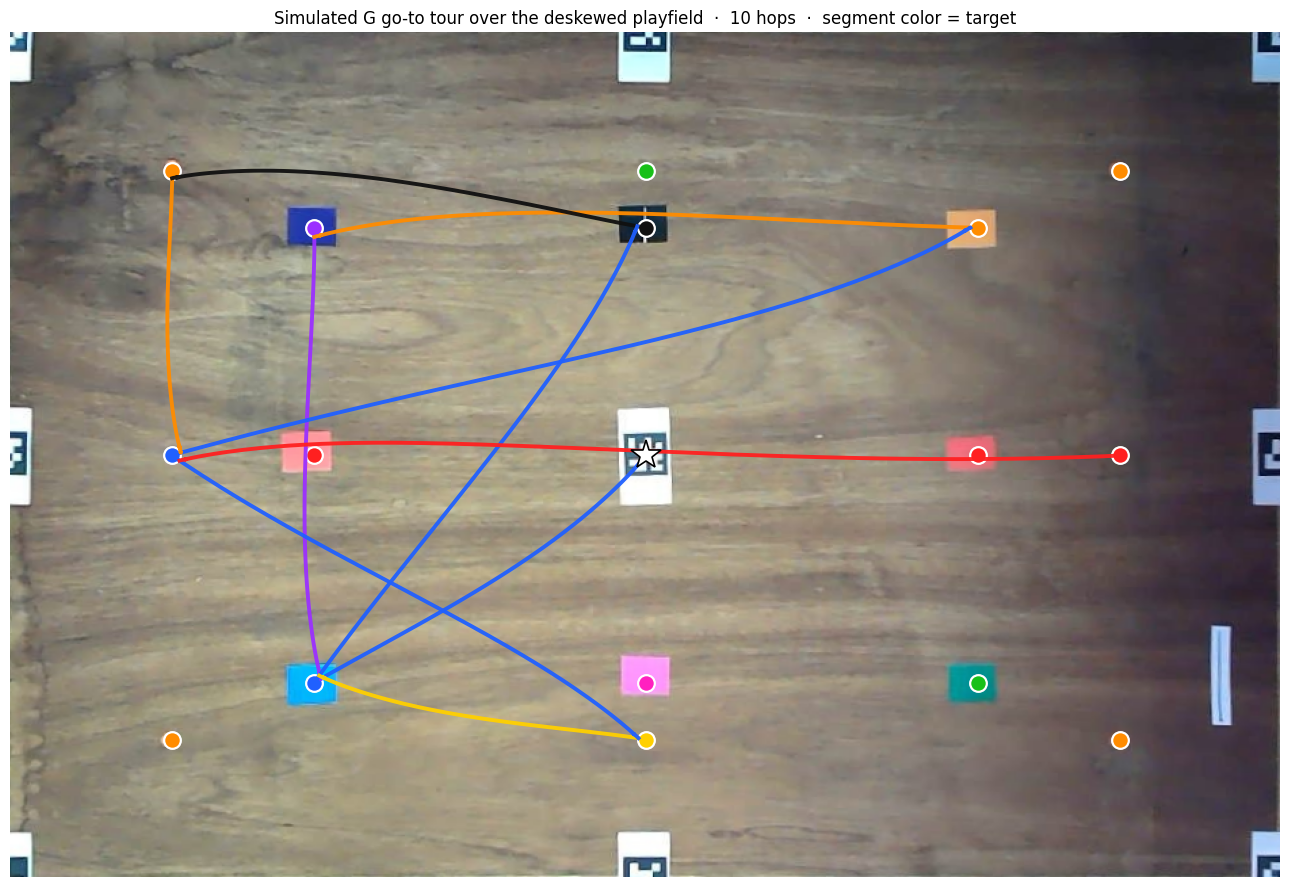

In [3]:
fig, ax = plt.subplots(figsize=(13, 9))
ax.imshow(img)
for color, x, y in SITES:
    px, py = world_to_pixel(x, y)
    ax.plot(px, py, 'o', ms=12, mfc=CMAP.get(color, 'white'), mec='white', mew=1.6, zorder=3)
for color, (sx, sy), pts, (tx, ty) in segments:
    if not pts:
        continue
    xy = [world_to_pixel(wx, wy) for (wx, wy) in [(sx, sy)] + pts]
    ax.plot([p[0] for p in xy], [p[1] for p in xy], '-', lw=2.8,
            color=CMAP.get(color, 'white'), alpha=0.95, zorder=4)
spx, spy = world_to_pixel(0, 0)
ax.plot(spx, spy, '*', ms=22, mfc='white', mec='black', mew=1.2, zorder=5)
ax.set_xlim(0, IMG_W); ax.set_ylim(IMG_H, 0)
ax.set_title(f"Simulated G go-to tour over the deskewed playfield  ·  {len(segments)} hops  ·  "
             "segment color = target", fontsize=12)
ax.axis('off'); plt.tight_layout(); plt.show()